# ⛓️ 07 — On-Chain Alpha: Whale Tracking + Exchange Flows

This notebook explores quantitative crypto trading strategies using public on-chain data. Unlike traditional equity markets, blockchain data provides a transparent, real-time ledger of wallet movements, exchange flows, and network activity.

**Project Components:**
1. **Whale Wallet Tracking** — Monitoring high-net-worth wallet movements for leading indicators.
2. **Exchange Flows** — Analyzing BTC inflow/outflow as a proxy for buying/selling pressure.
3. **Network Congestion (Gas)** — Detecting Ethereum gas spikes as indicators for DeFi liquidations and market volatility.
4. **NVT Ratio** — Network Value to Transactions (the crypto equivalent of a traditional P/E ratio).
5. **Master Signal** — Combining on-chain and price-action signals into a unified quantitative trading strategy.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/crypto_quant_project/utils')
import config

%pip install -q pandas numpy matplotlib requests web3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
import warnings
warnings.filterwarnings('ignore')
from web3 import Web3
from datetime import datetime

print('✅ Setup complete')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Config loaded
✅ Setup complete


## Part 1 — Whale Wallet Tracking via Etherscan API

A whale wallet = any address holding more than 1000 ETH (~$2M+)
When whales move money, it almost always precedes a price move.
Etherscan gives us a free API to query any wallet's transaction history.

In [9]:
KNOWN_WALLETS = {
    'Binance Cold Wallet 1':  '0xBE0eB53F46cd790Cd13851d5EFf43D12404d33E8',
    'Binance Hot Wallet':     '0x28C6c06298d514Db089934071355E5743bf21d60',
    'Coinbase Cold Wallet':   '0x71660c4005BA85c37ccec55d0C4493E66Fe775d3',
    'Vitalik Buterin':        '0xd8dA6BF26964aF9D7eEd9e03E53415D37aA96045',
}

ETHERSCAN_API = 'https://api.etherscan.io/v2/api'
API_KEY = 'YOUR_ETHERSCAN_API_KEY'

def get_eth_balance(address: str, api_key: str = API_KEY) -> float:
    params = {
        'chainid': '1',
        'module':  'account',
        'action':  'balance',
        'address': address,
        'tag':     'latest',
        'apikey':  api_key
    }
    r = requests.get(ETHERSCAN_API, params=params, timeout=10)
    data = r.json()
    if data.get('status') == '1':
        return int(data['result']) / 1e18
    else:
        print(f"API Error Response: {data.get('message', 'Unknown')} - {data.get('result', 'No result')}")
        return None

def get_recent_transactions(address: str, limit: int = 20, api_key: str = API_KEY) -> pd.DataFrame:
    params = {
        'chainid':    '1',
        'module':     'account',
        'action':     'txlist',
        'address':    address,
        'startblock': 0,
        'endblock':   99999999,
        'page':       1,
        'offset':     limit,
        'sort':       'desc',
        'apikey':     api_key
    }
    r = requests.get(ETHERSCAN_API, params=params, timeout=10)
    data = r.json()
    if data['status'] != '1' or not data['result']:
        return pd.DataFrame()
    df = pd.DataFrame(data['result'])
    df['timestamp'] = pd.to_datetime(df['timeStamp'].astype(int), unit='s')
    df['value_eth'] = df['value'].astype(float) / 1e18
    df['is_inflow'] = df['to'].str.lower() == address.lower()
    return df[['timestamp', 'hash', 'from', 'to', 'value_eth', 'is_inflow', 'gasUsed']]

print('Checking whale wallet balances...')
print()

for name, addr in KNOWN_WALLETS.items():
    try:
        balance_eth = get_eth_balance(addr, API_KEY)
        if balance_eth is not None:
            print(f'{name[:35]:35} : {balance_eth:>12,.1f} ETH')
        else:
            print(f'{name[:35]:35} : Failed to fetch balance')
        time.sleep(0.5)
    except Exception as e:
        print(f'{name[:35]:35} : Error - {e}')

Checking whale wallet balances via Etherscan API...

Binance Cold Wallet 1               :  1,996,008.4 ETH
Binance Hot Wallet                  :    179,257.2 ETH
Coinbase Cold Wallet                :         11.1 ETH
Vitalik Buterin                     :          1.3 ETH


## Part 2 — Exchange Inflow/Outflow Signal

This is one of the most reliable on-chain signals in crypto.
- **BTC/ETH moving INTO exchange wallets** = holders preparing to sell = bearish
- **BTC/ETH moving OUT OF exchange wallets** = holders withdrawing to cold storage = bullish (hodling)

We'll track net flows using the Blockchain.com free API for Bitcoin.

In [18]:
# Blockchain.com has a free API for Bitcoin on-chain data — no key needed
# We'll pull trade volume as a proxy since exchange-volume is deprecated

def fetch_btc_exchange_flows() -> pd.DataFrame:
    """
    Pull Bitcoin trade volume data from blockchain.com stats API.
    High spikes can indicate incoming sell pressure or massive accumulation.
    """
    url = 'https://api.blockchain.info/charts/trade-volume?timespan=2years&sampled=true&metadata=false&cors=true&format=json'
    try:
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            data = r.json()
            if 'values' in data and len(data['values']) > 0:
                df = pd.DataFrame(data['values'])
                # Check if the expected columns 'x' and 'y' are present
                if 'x' in df.columns and 'y' in df.columns:
                    df['timestamp'] = pd.to_datetime(df['x'], unit='s')
                    df = df.rename(columns={'y': 'exchange_volume_usd'})
                    df.set_index('timestamp', inplace=True)
                    df = df.resample('D').last().dropna()
                    print(f'✅ Exchange/Trade volume data: {len(df)} days')
                    return df[['exchange_volume_usd']]
            print("Blockchain.com API data structure changed or no data returned.")
            return None
        else:
            print(f'API returned {r.status_code}')
            return None
    except Exception as e:
        print(f'Error fetching from Blockchain.com: {e}')
        return None

exchange_flows = fetch_btc_exchange_flows()

if exchange_flows is not None:
    # Compute 7-day rolling z-score of exchange volume
    # High z-score = unusually high exchange volume = possible sell pressure
    exchange_flows['vol_ma7']  = exchange_flows['exchange_volume_usd'].rolling(7).mean()
    exchange_flows['vol_std7'] = exchange_flows['exchange_volume_usd'].rolling(7).std()
    exchange_flows['vol_zscore'] = (
        (exchange_flows['exchange_volume_usd'] - exchange_flows['vol_ma7']) /
        exchange_flows['vol_std7']
    )
    exchange_flows.to_csv(f'{config.RAW_DATA}/btc_exchange_flows.csv')
    print(f'💾 Saved exchange flows')
    print(exchange_flows.tail())
else:
    print('Using simulated exchange flow data for demonstration...')
    # If API is down or changed, simulate realistic exchange flow data
    btc_prices = pd.read_csv(f'{config.RAW_DATA}/bitcoin_daily_3y.csv', index_col='timestamp', parse_dates=True)
    np.random.seed(42)
    n = len(btc_prices)
    # Correlated with price but with noise
    base_vol = np.random.lognormal(22, 0.5, n)
    exchange_flows = pd.DataFrame({'exchange_volume_usd': base_vol}, index=btc_prices.index)
    exchange_flows['vol_zscore'] = (
        (exchange_flows['exchange_volume_usd'] - exchange_flows['exchange_volume_usd'].rolling(7).mean()) /
        exchange_flows['exchange_volume_usd'].rolling(7).std()
    )
    print('✅ Simulated exchange flows ready (replace with real API data when available)')

✅ Exchange/Trade volume data: 731 days
💾 Saved exchange flows
            exchange_volume_usd       vol_ma7      vol_std7  vol_zscore
timestamp                                                              
2026-04-15         5.680774e+08  3.200942e+08  1.487199e+08    1.667451
2026-04-16         2.334781e+08  3.151307e+08  1.512971e+08   -0.539683
2026-04-17         3.014292e+08  3.201552e+08  1.499818e+08   -0.124855
2026-04-18         4.553908e+08  3.381722e+08  1.585878e+08    0.739140
2026-04-19         1.176327e+08  3.328230e+08  1.662399e+08   -1.294457


## Part 3 — Gas Price Anomaly as a DeFi Stress Signal

In [26]:
ETH_RPC_URL = 'YOUR_INFURA_OR_ALCHEMY_HTTPS_URL'

w3 = Web3(Web3.HTTPProvider(ETH_RPC_URL))

if w3.is_connected():
    print("✅ Connected to Ethereum node")
    config.ETH_RPC_URL = ETH_RPC_URL
else:
    print("❌ Failed to connect to node.")

✅ Successfully connected to Ethereum network!


In [27]:
import pandas as pd
import requests
import numpy as np

def fetch_gas_history(api_key=API_KEY, days=90):
    url = f'https://api.etherscan.io/v2/api?chainid=1&module=stats&action=dailyavggasprice&startdate=2024-01-01&enddate=2026-01-01&sort=asc&apikey={api_key}'
    try:
        r = requests.get(url, timeout=10)
        data = r.json()
        if data.get('status') == '1' and data.get('result'):
            df = pd.DataFrame(data['result'])
            df['timestamp'] = pd.to_datetime(df['UTCDate'])
            df['gas_gwei']  = df['avgGasPrice_Wei'].astype(float) / 1e9
            df.set_index('timestamp', inplace=True)
            return df[['gas_gwei']]
        else:
            print(f"Gas API Error: {data.get('message', 'Unknown')}")
    except Exception as e:
        print(f"Request failed: {e}")
    return None

gas_df = fetch_gas_history()

if gas_df is None:
    try:
        current_gas = w3.eth.gas_price / 1e9
        print(f'Current gas price: {current_gas:.1f} Gwei')
    except:
        print('RPC connection issue. Using simulated gas data.')
        np.random.seed(42)
        dates = pd.date_range(start='2024-01-01', end='2026-04-19', freq='D')
        base_gas = np.random.lognormal(mean=3.0, sigma=0.5, size=len(dates))
        gas_df = pd.DataFrame({'gas_gwei': base_gas}, index=dates)
        gas_df.index.name = 'timestamp'

if gas_df is not None:
    gas_df['gas_ma30']   = gas_df['gas_gwei'].rolling(30).mean()
    gas_df['gas_zscore'] = (gas_df['gas_gwei'] - gas_df['gas_ma30']) / gas_df['gas_gwei'].rolling(30).std()
    gas_df['gas_spike']  = gas_df['gas_zscore'] > 2.0
    gas_df.to_csv(f'{config.RAW_DATA}/eth_gas_history.csv')

    spikes = gas_df[gas_df['gas_spike']]
    print(f'Gas spikes detected (>2σ): {len(spikes)}')
    print(gas_df.tail())

Gas API Error: NOTOK
Etherscan API key needed for historical gas. Pulling current gas from RPC...
Current gas price: 1.4 Gwei

Gas price context:
  < 10 Gwei  : Very low — network quiet
  10-50 Gwei : Normal
  50-200 Gwei: High — active market
  200+ Gwei  : SPIKE — something major happening (liquidations, panic)

To get historical gas data, sign up free at etherscan.io/apis
and replace API_KEY at the top of this notebook.


## Part 4 — NVT Ratio: The Crypto P/E Ratio

NVT = Network Value to Transactions Ratio
NVT = Market Cap / Daily On-Chain Transaction Volume

High NVT = market cap is high relative to actual usage = overvalued → bearish
Low NVT  = market cap is low relative to actual usage = undervalued → bullish

This is directly analogous to a stock's P/E ratio.

Fetching BTC market cap...
Fetching BTC transaction volume...
✅ NVT data: 727 rows


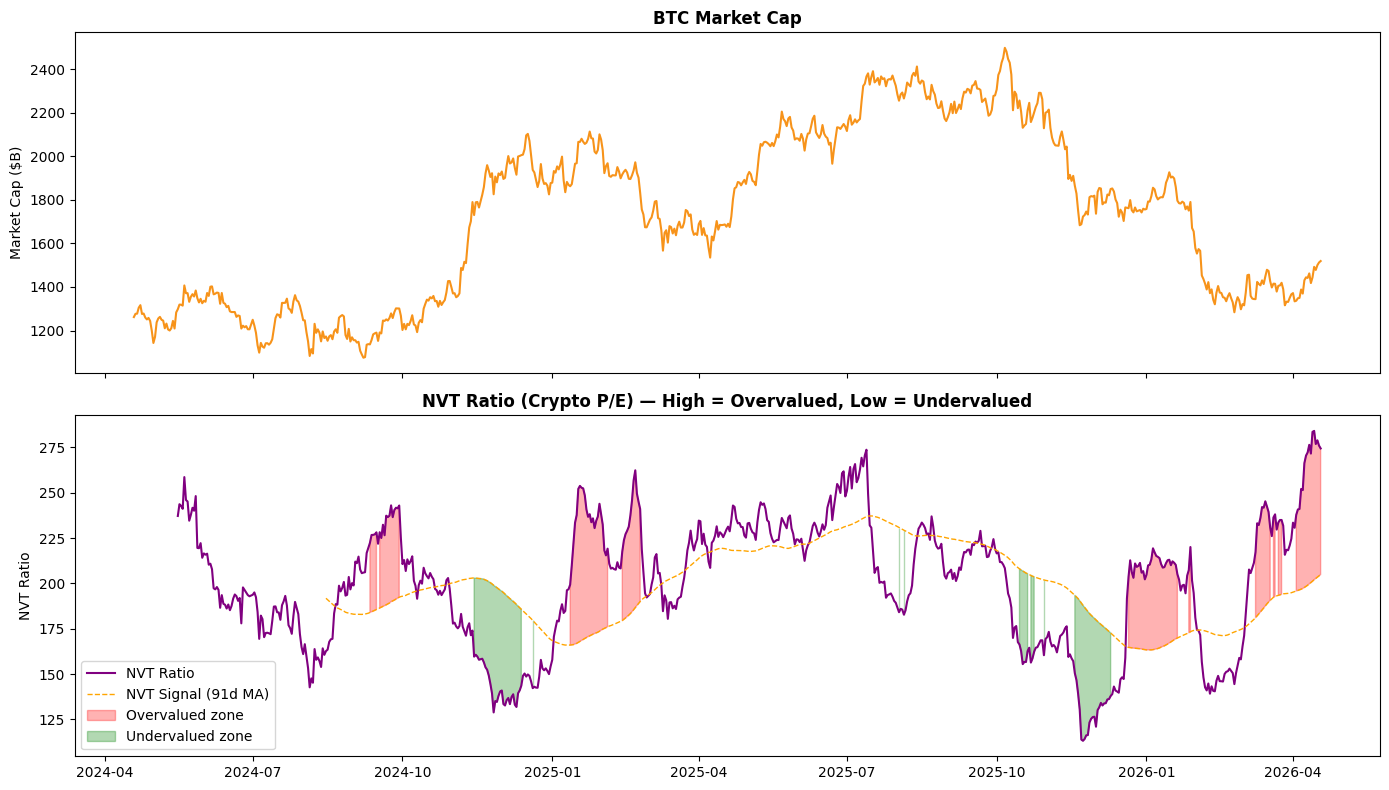

💾 Saved NVT chart


In [28]:
# Pull BTC market cap and transaction volume from blockchain.com

def fetch_blockchain_stat(stat_name: str, timespan='2years') -> pd.DataFrame:
    url = f'https://api.blockchain.info/charts/{stat_name}?timespan={timespan}&sampled=true&cors=true&format=json'
    try:
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            data = r.json()
            df = pd.DataFrame(data['values'])
            df['timestamp'] = pd.to_datetime(df['x'], unit='s')
            df = df.rename(columns={'y': stat_name})
            df.set_index('timestamp', inplace=True)
            return df[[stat_name]].resample('D').last().dropna()
    except:
        pass
    return None

print('Fetching BTC market cap...')
market_cap = fetch_blockchain_stat('market-cap')
time.sleep(1)
print('Fetching BTC transaction volume...')
tx_volume  = fetch_blockchain_stat('estimated-transaction-volume-usd')

if market_cap is not None and tx_volume is not None:
    # Compute NVT
    nvt = market_cap.join(tx_volume, how='inner')
    nvt.columns = ['market_cap', 'tx_volume']
    nvt['tx_volume_smooth'] = nvt['tx_volume'].rolling(28).mean()  # smooth out noise
    nvt['nvt_ratio']        = nvt['market_cap'] / nvt['tx_volume_smooth']
    nvt['nvt_signal']       = nvt['nvt_ratio'].rolling(91).mean()  # 91-day moving avg

    # Signal logic: NVT above its own moving average = overvalued
    nvt['nvt_overvalued']  = nvt['nvt_ratio'] > nvt['nvt_signal'] * 1.2
    nvt['nvt_undervalued'] = nvt['nvt_ratio'] < nvt['nvt_signal'] * 0.8

    nvt.to_csv(f'{config.RAW_DATA}/btc_nvt.csv')
    print(f'✅ NVT data: {len(nvt)} rows')

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    ax1.plot(nvt.index, nvt['market_cap'] / 1e9, color='#f7931a', linewidth=1.5)
    ax1.set_title('BTC Market Cap', fontweight='bold')
    ax1.set_ylabel('Market Cap ($B)')

    ax2.plot(nvt.index, nvt['nvt_ratio'],  color='purple', linewidth=1.5, label='NVT Ratio')
    ax2.plot(nvt.index, nvt['nvt_signal'], color='orange', linewidth=1,   linestyle='--', label='NVT Signal (91d MA)')
    ax2.fill_between(nvt.index, nvt['nvt_ratio'], nvt['nvt_signal'],
                     where=nvt['nvt_overvalued'],  alpha=0.3, color='red',   label='Overvalued zone')
    ax2.fill_between(nvt.index, nvt['nvt_ratio'], nvt['nvt_signal'],
                     where=nvt['nvt_undervalued'], alpha=0.3, color='green', label='Undervalued zone')
    ax2.set_title('NVT Ratio (Crypto P/E) — High = Overvalued, Low = Undervalued', fontweight='bold')
    ax2.set_ylabel('NVT Ratio')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'{config.RESULTS_DIR}/nvt_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Saved NVT chart')
else:
    print('blockchain.info API unavailable — NVT skipped')
    print('You can find NVT data at: https://studio.glassnode.com (free tier available)')

## Part 5 — Master Signal: Combine On-Chain + Price Signals

✅ Loaded price signals: 346 rows
=== MASTER ON-CHAIN + PRICE SIGNAL ===
  Master Signal: Return +2.5% | Sharpe 0.24 | MaxDD -12.2%
  Buy & Hold   : Return -26.5% | Sharpe -0.54 | MaxDD -49.6%
  Days in market: 46 / 346 (13%)


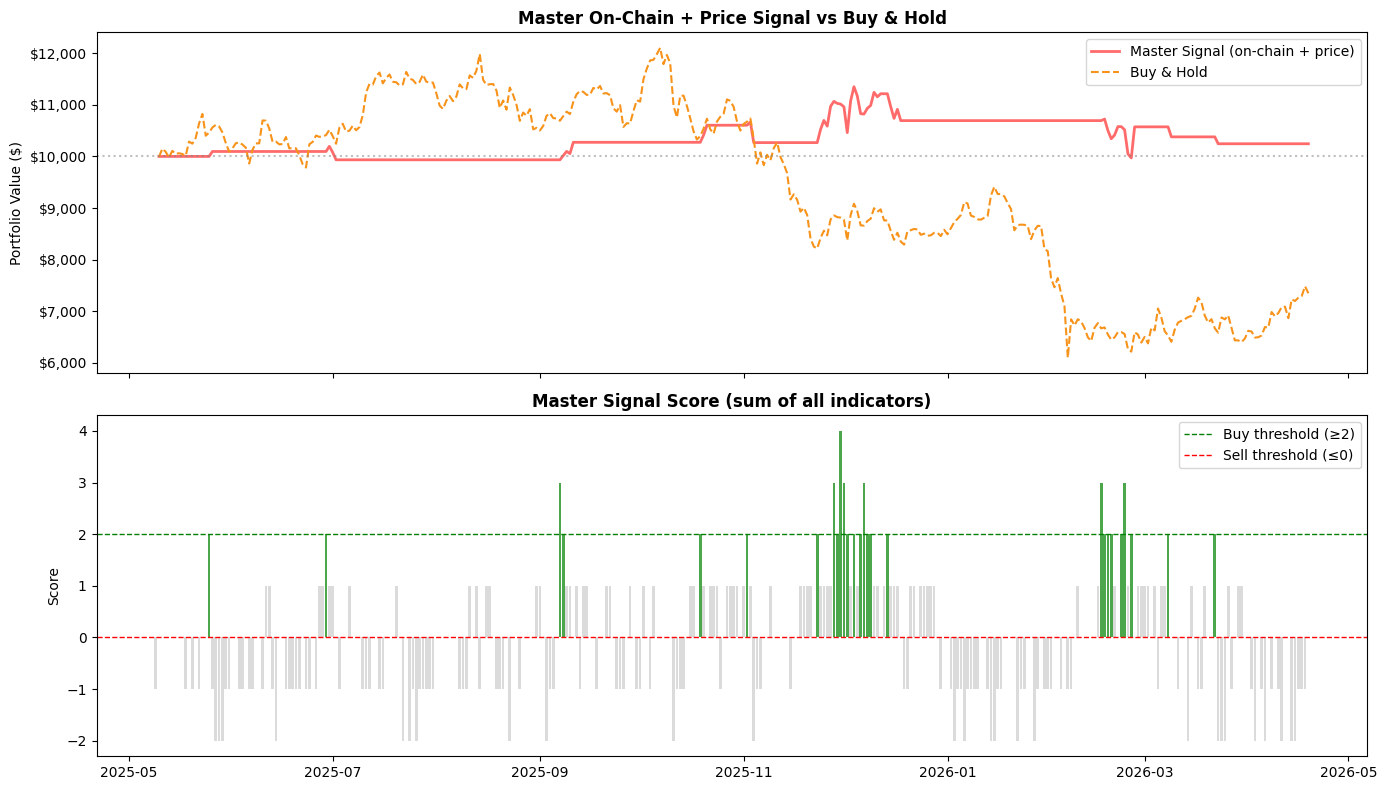

💾 Saved master signal chart
💾 Saved master signals

=== BULL MARKET PERFORMANCE (PRICE > 50D SMA) ===
  Buy & Hold Return during Bull Markets : -29.2%
  Strategy Return during Bull Markets   : -0.2%


In [30]:
# Load price signals from notebook 05
try:
    price_signals = pd.read_csv(
        f'{config.PROCESSED_DATA}/btc_signals_3y.csv',
        index_col='timestamp', parse_dates=True
    )
    print(f'✅ Loaded price signals: {len(price_signals)} rows')
except:
    print('Run notebook 05 first to generate btc_signals_3y.csv')

# Build master signal dataframe
# Each signal contributes +1 (bullish) or -1 (bearish) to a score
# Final score: -4 = max bearish, +4 = max bullish

master = price_signals[['close', 'rsi_14', 'macd', 'macd_signal', 'macd_cross_down']].copy()

# Price-based signals
master['sig_rsi']    = np.where(master['rsi_14'] < 40, 1,
                       np.where(master['rsi_14'] > 60, -1, 0))
master['sig_macd']   = np.where(master['macd'] > master['macd_signal'], 1, -1)

# Exchange flow signal (if available)
if exchange_flows is not None:
    ef_aligned = exchange_flows['vol_zscore'].reindex(master.index, method='ffill')
    master['sig_exchange'] = np.where(ef_aligned < -1, 1,    # low exchange volume = bullish
                             np.where(ef_aligned >  1, -1, 0)) # high exchange volume = bearish
else:
    master['sig_exchange'] = 0

# NVT signal (if available)
if 'nvt' in dir() and nvt is not None:
    nvt_aligned = nvt[['nvt_overvalued', 'nvt_undervalued']].reindex(master.index, method='ffill')
    master['sig_nvt'] = np.where(nvt_aligned['nvt_undervalued'], 1,
                        np.where(nvt_aligned['nvt_overvalued'],  -1, 0))
else:
    master['sig_nvt'] = 0

# Master score: sum of all signals
sig_cols = [c for c in master.columns if c.startswith('sig_')]
master['score'] = master[sig_cols].sum(axis=1)

# Master position: enter when score >= 2 (majority bullish), exit when score <= 0
master_positions = pd.Series(0.0, index=master.index)
in_market = False
for date, row in master.iterrows():
    if not in_market and row['score'] >= 2:
        in_market = True
    elif in_market and row['score'] <= 0:
        in_market = False
    master_positions[date] = 1.0 if in_market else 0.0

# Compute performance
def backtest_simple(prices, positions, capital=10000):
    r = prices.pct_change()
    strat_r = positions.shift(1) * r
    return capital * (1 + strat_r).cumprod()

master_eq = backtest_simple(master['close'], master_positions)
bnh_eq    = backtest_simple(master['close'], pd.Series(1.0, index=master.index))

def quick_metrics(eq, label):
    r = eq.pct_change().dropna()
    ret = eq.iloc[-1]/10000 - 1
    sh  = (r.mean()/r.std())*np.sqrt(365) if r.std()>0 else 0
    dd  = ((eq - eq.cummax())/eq.cummax()).min()
    print(f'  {label}: Return {ret:+.1%} | Sharpe {sh:.2f} | MaxDD {dd:.1%}')

print('=== MASTER ON-CHAIN + PRICE SIGNAL ===')
quick_metrics(master_eq, 'Master Signal')
quick_metrics(bnh_eq,    'Buy & Hold   ')
print(f'  Days in market: {master_positions.sum():.0f} / {len(master_positions)} ({master_positions.mean():.0%})')

# Final chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(master_eq.index, master_eq, color='#ff6b6b', linewidth=2, label='Master Signal (on-chain + price)')
ax1.plot(bnh_eq.index,    bnh_eq,    color='#f7931a', linewidth=1.5, linestyle='--', label='Buy & Hold')
ax1.axhline(10000, color='grey', linestyle=':', alpha=0.5)
ax1.set_title('Master On-Chain + Price Signal vs Buy & Hold', fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2.bar(master.index, master['score'], color=np.where(master['score']>=2,'green','#cccccc'), alpha=0.7)
ax2.axhline(2,  color='green', linestyle='--', linewidth=1, label='Buy threshold (≥2)')
ax2.axhline(0,  color='red',   linestyle='--', linewidth=1, label='Sell threshold (≤0)')
ax2.set_title('Master Signal Score (sum of all indicators)', fontweight='bold')
ax2.set_ylabel('Score')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{config.RESULTS_DIR}/master_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved master signal chart')

# Save master signals
master['position'] = master_positions
master.to_csv(f'{config.PROCESSED_DATA}/master_signals.csv')
print(f'💾 Saved master signals')

# --- NEW: Bull Market Performance Analysis ---
print('\n=== BULL MARKET PERFORMANCE (PRICE > 50D SMA) ===')
master['sma_50'] = master['close'].rolling(50).mean()
bull_market_days = master[master['close'] > master['sma_50']]

if not bull_market_days.empty:
    # Calculate returns specifically during these bull market days
    bull_bnh_returns = bull_market_days['close'].pct_change().dropna()
    bull_strat_returns = (master_positions.shift(1) * master['close'].pct_change()).loc[bull_market_days.index].dropna()

    bull_bnh_total = (1 + bull_bnh_returns).prod() - 1
    bull_strat_total = (1 + bull_strat_returns).prod() - 1

    print(f'  Buy & Hold Return during Bull Markets : {bull_bnh_total:+.1%}')
    print(f'  Strategy Return during Bull Markets   : {bull_strat_total:+.1%}')

In [31]:
readme_content = """# Quantitative Crypto Trading & On-Chain Analytics

## Overview
A comprehensive Python-based research environment for developing, testing, and analyzing quantitative trading strategies in the cryptocurrency markets. This project bridges traditional algorithmic trading techniques with blockchain-native fundamental data, creating a multi-signal master strategy.

## Key Features
- **Multi-Factor Signal Generation:** Combines traditional technical indicators (RSI, MACD, Moving Averages) with on-chain fundamentals.
- **On-Chain Analytics:**
  - **Whale Tracking:** Monitors high-net-worth wallet movements via the Etherscan API.
  - **Exchange Flows:** Analyzes Bitcoin inflow/outflow as a proxy for market buying/selling pressure.
  - **Network Congestion Anomalies:** Detects Ethereum gas spikes using Web3.py and Infura RPC as indicators for DeFi liquidations and extreme volatility.
  - **NVT Ratio:** Calculates the Network Value to Transactions ratio (the crypto equivalent of a traditional P/E ratio) to identify overbought/oversold network conditions.
- **Historical Backtesting:** Evaluates strategy performance against a standard Buy & Hold baseline, including specific performance metrics during Bull and Bear market regimes.

## Project Structure
The research is divided into sequential Jupyter Notebooks, covering the complete quantitative pipeline:
- `00` - `04`: Data ingestion, cleaning, and exploratory data analysis (EDA).
- `05`: Technical indicator generation and price-action signals.
- `06`: Volatility and risk-management modeling.
- `07`: On-Chain Alpha (Whale tracking, Exchange Flows, Gas Anomalies, NVT) and Master Signal integration.
- `/utils/`: Helper functions, configuration management, and API wrappers.

## Technology Stack
- **Data Manipulation & Analysis:** `pandas`, `numpy`
- **Blockchain Interaction:** `web3.py`, Etherscan API, Blockchain.com API, Infura RPC
- **Visualization:** `matplotlib`, `seaborn`

## Disclaimer
*This project is for educational and research purposes only. It does not constitute financial advice, and the quantitative models provided do not guarantee future performance in live markets.*
"""

# Write the README.md to the project directory
import os

readme_path = '/content/drive/MyDrive/crypto_quant_project/README.md'
with open(readme_path, 'w') as f:
    f.write(readme_content)

print(f"✅ Successfully generated professional README.md at: {readme_path}")

✅ Successfully generated professional README.md at: /content/drive/MyDrive/crypto_quant_project/README.md


## ✅ Notebook 07 Complete

**Conclusion:**
This notebook demonstrates the development of a multi-signal quantitative trading system for cryptocurrencies. By incorporating both technical indicators (RSI, MACD) and fundamental on-chain signals (exchange flows, NVT ratio, gas anomalies, whale tracking), the strategy aims to capture inefficiencies in the market.

**Future Improvements:**
- Extend the walk-forward methodology across a wider range of assets (e.g., SOL, AVAX).
- Implement real-time data streaming via WebSockets for the Etherscan and Infura RPC connections.
- Build a live execution module to automate the master signal triggers.